# HW3

In [41]:
import numpy as np
from matrix_operation import m_lambda_i
import matplotlib.pyplot as plt
%matplotlib inline

## Random Data Generator

In [42]:
def Normal(mean, varience):
    u = np.random.uniform(0, 1)
    v = np.random.uniform(0, 1)
    x = np.sqrt(-2 * np.log(u)) * np.cos(2 * np.pi * v)
    return x * np.sqrt(varience) + mean

def Polynomial(n, a, w):
    x = np.random.uniform(-1, 1)
    phi = [x**i for i in range(n)]
    return [x, np.dot(phi, w) + Normal(0, a)]

## Sequential Estimator

In [43]:
mean = 3.0
varience = 5.0

In [44]:
n = 0
sample_mean = 0.0
sample_varience = 0.0
square_sum = 0.0
prev_sample_mean = np.inf
prev_sample_varience = np.inf
threshold = 0.0001

print(f"Data point source function: N({mean}, {varience})", end="\n\n")

while True:
    n += 1
    new_data = Normal(mean, varience)
    sample_mean = (sample_mean * (n - 1) + new_data) / n
    
    square_sum += new_data**2
    if n != 1:  sample_varience = (square_sum / n - sample_mean**2) * n / (n - 1)

    print(f"Add data point: {new_data}")
    print(f"Mean = {sample_mean} Variance = {sample_varience}")

    if abs(sample_mean - prev_sample_mean) < threshold and abs(sample_varience - prev_sample_varience) < threshold:
        break

    prev_sample_mean = sample_mean
    prev_sample_varience = sample_varience

Data point source function: N(3.0, 5.0)

Add data point: 1.5019738499043314
Mean = 1.5019738499043314 Variance = 0.0
Add data point: 7.208721877259912
Mean = 4.3553478635821214 Variance = 16.283486523863417
Add data point: 3.2015588568425977
Mean = 3.97075152800228 Variance = 8.585486285956033
Add data point: -0.8491806955657188
Mean = 2.76576847211028 Variance = 11.53159418391798
Add data point: 5.345415776839812
Mean = 3.2816979330561864 Variance = 9.979611681298152
Add data point: 4.805355093323606
Mean = 3.535640793100756 Variance = 8.37061120204422
Add data point: -0.8582733721301588
Mean = 2.9079387694963397 Variance = 9.733578148096404
Add data point: 5.6632013920784035
Mean = 3.2523465973190975 Variance = 9.292000999007357
Add data point: 1.7731199572239837
Mean = 3.0879880817529735 Variance = 8.373624368883332
Add data point: 2.3209275047109696
Mean = 3.011282024048773 Variance = 7.502059854114831
Add data point: 3.949399771456263
Mean = 3.096565455631272 Variance = 6.83185976

## Bayesian Linear Regression

In [45]:
b = 100
n = 4
a = 1
w = np.array([1, 2, 3, 4])
threshold = 1e-7


In [46]:
def makeplot(ax, a, x, y, mean, variance, title, scatter):
    t = np.linspace(-2, 2, 500)
    mean_line = np.zeros(500)
    variance_line = np.zeros(500)
    for i in range(500):
        phi = np.array([t[i]**j for j in range(n)]).reshape(n, 1)
        mean_line[i] = (mean.T.dot(phi)).item(0)
        variance_line[i] = (phi.T.dot(variance).dot(phi) + a).item(0)

    if scatter:
        ax.scatter(x, y, color='blue')
    ax.plot(t, mean_line, color='black')
    ax.plot(t, mean_line + variance_line, color='red')
    ax.plot(t, mean_line - variance_line, color='red')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-20, 20)
    ax.set_title(title)

Add data point 1 (-0.30352153501019097, -0.088777150661706):

Posterior mean:
[[-8.78100162e-04]
 [ 2.66522309e-04]
 [-8.08952603e-05]
 [ 2.45534536e-05]]

Posterior variance:
[[ 9.90108940e-03  3.00214984e-05 -9.11217129e-06  2.76574022e-06]
 [ 3.00214984e-05  9.99088783e-03  2.76574022e-06 -8.39461716e-07]
 [-9.11217129e-06  2.76574022e-06  9.99916054e-03  2.54794709e-07]
 [ 2.76574022e-06 -8.39461716e-07  2.54794709e-07  9.99992266e-03]]

Predictive distribution ~ N(-0.0009671344881378463, 1.010893957295647)
Add data point 2 (-0.3195956917687117, 0.42739315965005215):

Posterior mean:
[[ 0.00331248]
 [-0.00107351]
 [ 0.0003476 ]
 [-0.00011246]]

Posterior variance:
[[ 9.80433370e-03  6.09614241e-05 -1.90056658e-05  5.92924509e-06]
 [ 6.09614241e-05  9.98099405e-03  5.92941951e-06 -1.85106736e-06]
 [-1.90056658e-05  5.92941951e-06  9.99814891e-03  5.78270433e-07]
 [ 5.92924509e-06 -1.85106736e-06  5.78270433e-07  9.99981923e-03]]

Predictive distribution ~ N(0.0036947440269505015, 1.

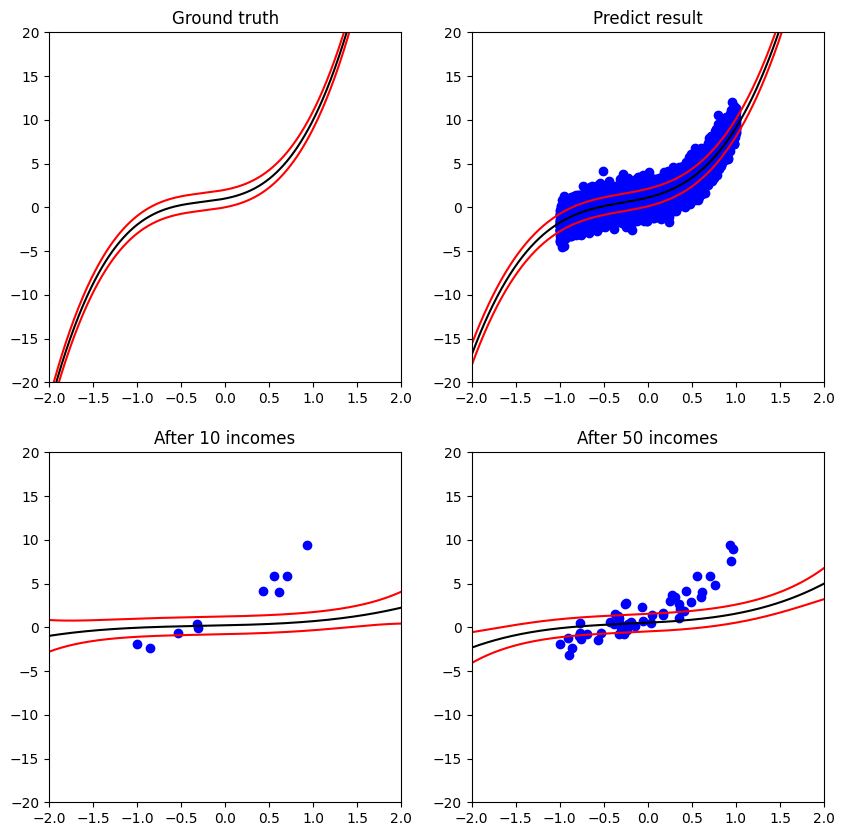

In [47]:
prior_mean = np.array([0 for i in range(n)]).reshape(n, 1)
prior_lambda = m_lambda_i(n, b)
prev_predictive_variance = np.inf

data_x = []
data_y = []
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

count = 0

while count < 10000:
    count += 1

    x, y = Polynomial(n, a, w)
    data_x.append(x)
    data_y.append(y)
    print(f"Add data point {count} ({x}, {y}):")

    phi = np.array([x**i for i in range(n)]).reshape(n, 1)
    posterior_lambda = prior_lambda + (1 / a) * phi.dot(phi.T)
    posterior_variance = np.linalg.inv(posterior_lambda)
    posterior_mean = posterior_variance.dot(phi * y / a + prior_lambda.dot(prior_mean))

    print("\nPosterior mean:")
    print(posterior_mean)
    print("\nPosterior variance:")
    print(posterior_variance)

    predictive_mean = posterior_mean.T.dot(phi).item(0)
    predictive_variance = phi.T.dot(posterior_variance).dot(phi).item(0) + a
    print(f"\nPredictive distribution ~ N({predictive_mean}, {predictive_variance})")
    print("="*80)

    if abs(prev_predictive_variance - predictive_variance) < threshold:
        break

    prior_mean = posterior_mean
    prior_lambda = posterior_lambda
    prev_predictive_variance = predictive_variance

    if count == 10:
        makeplot(axs[1, 0], a, data_x, data_y, posterior_mean, posterior_variance, "After 10 incomes", True)
    if count == 50:
        makeplot(axs[1, 1], a, data_x, data_y, posterior_mean, posterior_variance, "After 50 incomes", True)

makeplot(axs[0, 1], a, data_x, data_y, posterior_mean, posterior_variance, "Predict result", True)
makeplot(axs[0, 0], a, data_x, data_y, w, np.zeros((n,n)), "Ground truth", False)
plt.show()